# Beijing Air Quality Forecasting - Comprehensive Analysis

## Project Overview

This project focuses on forecasting PM2.5 air pollution levels in Beijing using Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) models. PM2.5 (particulate matter with diameter less than 2.5 micrometers) is a critical air quality indicator that affects public health.

### Objectives:
1. Preprocess sequential air quality and weather data
2. Design and train RNN/LSTM models for accurate PM2.5 prediction
3. Fine-tune models through systematic experimentation
4. Achieve RMSE below 4000 on the leaderboard
5. Analyze model performance and address RNN-specific challenges

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, GRU, SimpleRNN
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [5]:
# Load the datasets
# Loading from local data directory
# mount drive
from google.colab import drive
drive.mount('/content/drive')
#read from drive file

train = pd.read_csv('/content/drive/MyDrive/Kaggle_competition_ML/air_quality_forcasting/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Kaggle_competition_ML/air_quality_forcasting/test.csv')


print(f"Training data shape: {train.shape}")
print(f"Test data shape: {test.shape}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training data shape: (30676, 12)
Test data shape: (13148, 11)


In [6]:
# Display basic information about the datasets
print("DATASET OVERVIEW")
print("\nTraining Data Info:")
print(train.info())
print("\nTest Data Info:")
print(test.info())


DATASET OVERVIEW

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30676 entries, 0 to 30675
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   No        30676 non-null  int64  
 1   DEWP      30676 non-null  float64
 2   TEMP      30676 non-null  float64
 3   PRES      30676 non-null  float64
 4   Iws       30676 non-null  float64
 5   Is        30676 non-null  float64
 6   Ir        30676 non-null  float64
 7   datetime  30676 non-null  object 
 8   cbwd_NW   30676 non-null  float64
 9   cbwd_SE   30676 non-null  float64
 10  cbwd_cv   30676 non-null  float64
 11  pm2.5     28755 non-null  float64
dtypes: float64(10), int64(1), object(1)
memory usage: 2.8+ MB
None

Test Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13148 entries, 0 to 13147
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   No        13148 non-null  int6

# 1. DATA EXPLORATION AND ANALYSIS

## 1.1 Initial Data Inspection

Understanding the structure and content of our dataset is crucial before preprocessing. This section provides comprehensive statistics and visualizations to identify patterns, missing values, and relationships between features.

In [7]:

print("Column Names and Data Types:")
print(train.dtypes)
# Inspecting the first few rows of the dataset to understand its structure
print("Training Data - First 10 rows:")
print(train.head(10))

Column Names and Data Types:
No            int64
DEWP        float64
TEMP        float64
PRES        float64
Iws         float64
Is          float64
Ir          float64
datetime     object
cbwd_NW     float64
cbwd_SE     float64
cbwd_cv     float64
pm2.5       float64
dtype: object
Training Data - First 10 rows:
   No      DEWP      TEMP      PRES       Iws        Is        Ir  \
0   1 -1.580878 -1.922250  0.443328 -0.441894 -0.069353 -0.137667   
1   2 -1.580878 -2.004228  0.345943 -0.379306 -0.069353 -0.137667   
2   3 -1.580878 -1.922250  0.248559 -0.343514 -0.069353 -0.137667   
3   4 -1.580878 -2.168183  0.248559 -0.280926 -0.069353 -0.137667   
4   5 -1.511594 -2.004228  0.151174 -0.218339 -0.069353 -0.137667   
5   6 -1.442309 -1.840273  0.053790 -0.155751 -0.069353 -0.137667   
6   7 -1.442309 -1.758296  0.053790 -0.093164 -0.069353 -0.137667   
7   8 -1.442309 -1.758296  0.053790 -0.057371 -0.069353 -0.137667   
8   9 -1.442309 -1.758296  0.053790  0.005216 -0.069353 -0.137667

In [8]:
# Display column names
print(f"Target variable: pm2.5")
print(train.columns.tolist())
print(f"Features (excluding target): {len(train.columns) - 1}")


Target variable: pm2.5
['No', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'datetime', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv', 'pm2.5']
Features (excluding target): 11


In [9]:
# Convert datetime column to datetime format and set as index
# This is essential for time-series analysis as it allows proper temporal ordering
train['datetime'] = pd.to_datetime(train['datetime'])
test['datetime'] = pd.to_datetime(test['datetime'])

# Set datetime as index for better time-series handling
train_original = train.copy()
test_original = test.copy()
train.set_index('datetime', inplace=True)
test.set_index('datetime', inplace=True)

print("Datetime conversion completed.")
print(f"Training data time range: {train.index.min()} to {train.index.max()}")
print(f"Test data time range: {test.index.min()} to {test.index.max()}")
print(f"Total time span (training): {(train.index.max() - train.index.min()).days} days")


Datetime conversion completed.
Training data time range: 2010-01-01 00:00:00 to 2013-07-02 03:00:00
Test data time range: 2013-07-02 04:00:00 to 2014-12-31 23:00:00
Total time span (training): 1278 days


## 1.2 Missing Values Analysis

Missing values can significantly impact model performance. We need to:
1. Identify which features have missing values
2. Understand the pattern of missingness (random vs. systematic)
3. Choose appropriate imputation strategies based on the nature of the data

MISSING VALUES ANALYSIS

Missing values in Training Data:
pm2.5    1921
dtype: int64

Total missing values in training: 1921
Percentage of missing values: 6.26%

Missing values in Test Data:
Series([], dtype: int64)

Total missing values in test: 0


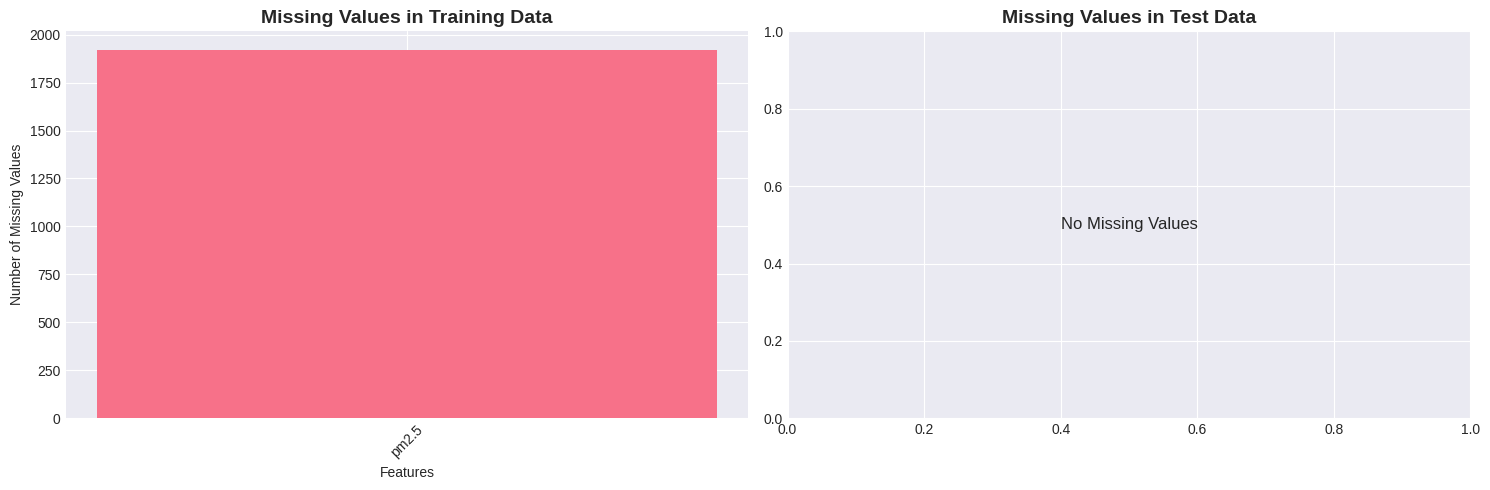


Missing values in target variable (pm2.5): 1921


In [10]:
# Comprehensive missing values analysis
print("MISSING VALUES ANALYSIS")

missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

print("\nMissing values in Training Data:")
print(missing_train[missing_train > 0])
print(f"\nTotal missing values in training: {missing_train.sum()}")
print(f"Percentage of missing values: {(missing_train.sum() / len(train) * 100):.2f}%")

print("\nMissing values in Test Data:")
print(missing_test[missing_test > 0])
print(f"\nTotal missing values in test: {missing_test.sum()}")

# Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training data missing values
missing_train_plot = missing_train[missing_train > 0]
if len(missing_train_plot) > 0:
    axes[0].bar(missing_train_plot.index, missing_train_plot.values)
    axes[0].set_title('Missing Values in Training Data', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Features')
    axes[0].set_ylabel('Number of Missing Values')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=12)
    axes[0].set_title('Missing Values in Training Data', fontsize=14, fontweight='bold')

# Test data missing values
missing_test_plot = missing_test[missing_test > 0]
if len(missing_test_plot) > 0:
    axes[1].bar(missing_test_plot.index, missing_test_plot.values, color='orange')
    axes[1].set_title('Missing Values in Test Data', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Features')
    axes[1].set_ylabel('Number of Missing Values')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=12)
    axes[1].set_title('Missing Values in Test Data', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Check if missing values are in target variable (pm2.5)
if 'pm2.5' in train.columns:
    pm25_missing = train['pm2.5'].isnull().sum()
    print(f"\nMissing values in target variable (pm2.5): {pm25_missing}")
    if pm25_missing > 0:
        print("WARNING: Target variable has missing values that need special handling!")


In [11]:
# Statistical summary of the dataset
print("STATISTICAL SUMMARY")
print("\nTraining Data Statistics:")
print(train.describe())

# Focus on target variable statistics
if 'pm2.5' in train.columns:
    print("TARGET VARIABLE (pm2.5) STATISTICS")
    pm25_stats = train['pm2.5'].describe()
    print(pm25_stats)
    print(f"\nSkewness: {train['pm2.5'].skew():.4f}")
    print(f"Kurtosis: {train['pm2.5'].kurtosis():.4f}")

STATISTICAL SUMMARY

Training Data Statistics:
                 No          DEWP          TEMP          PRES           Iws  \
count  30676.000000  30676.000000  30676.000000  30676.000000  30676.000000   
mean   15338.500000     -0.029431     -0.062712      0.013612      0.030542   
std     8855.542765      0.994087      1.015193      1.008991      1.018337   
min        1.000000     -2.135153     -2.578070     -2.380821     -0.468688   
25%     7669.750000     -0.888034     -0.938521     -0.822670     -0.441894   
50%    15338.500000     -0.056622      0.045209     -0.043595     -0.352512   
75%    23007.250000      0.913358      0.864984      0.832865      0.005216   
max    30676.000000      1.814055      2.340578      2.877939     11.231956   

                 Is            Ir       cbwd_NW       cbwd_SE       cbwd_cv  \
count  30676.000000  30676.000000  30676.000000  30676.000000  30676.000000   
mean       0.016992      0.011253      0.016193      0.005833     -0.025008   
std 

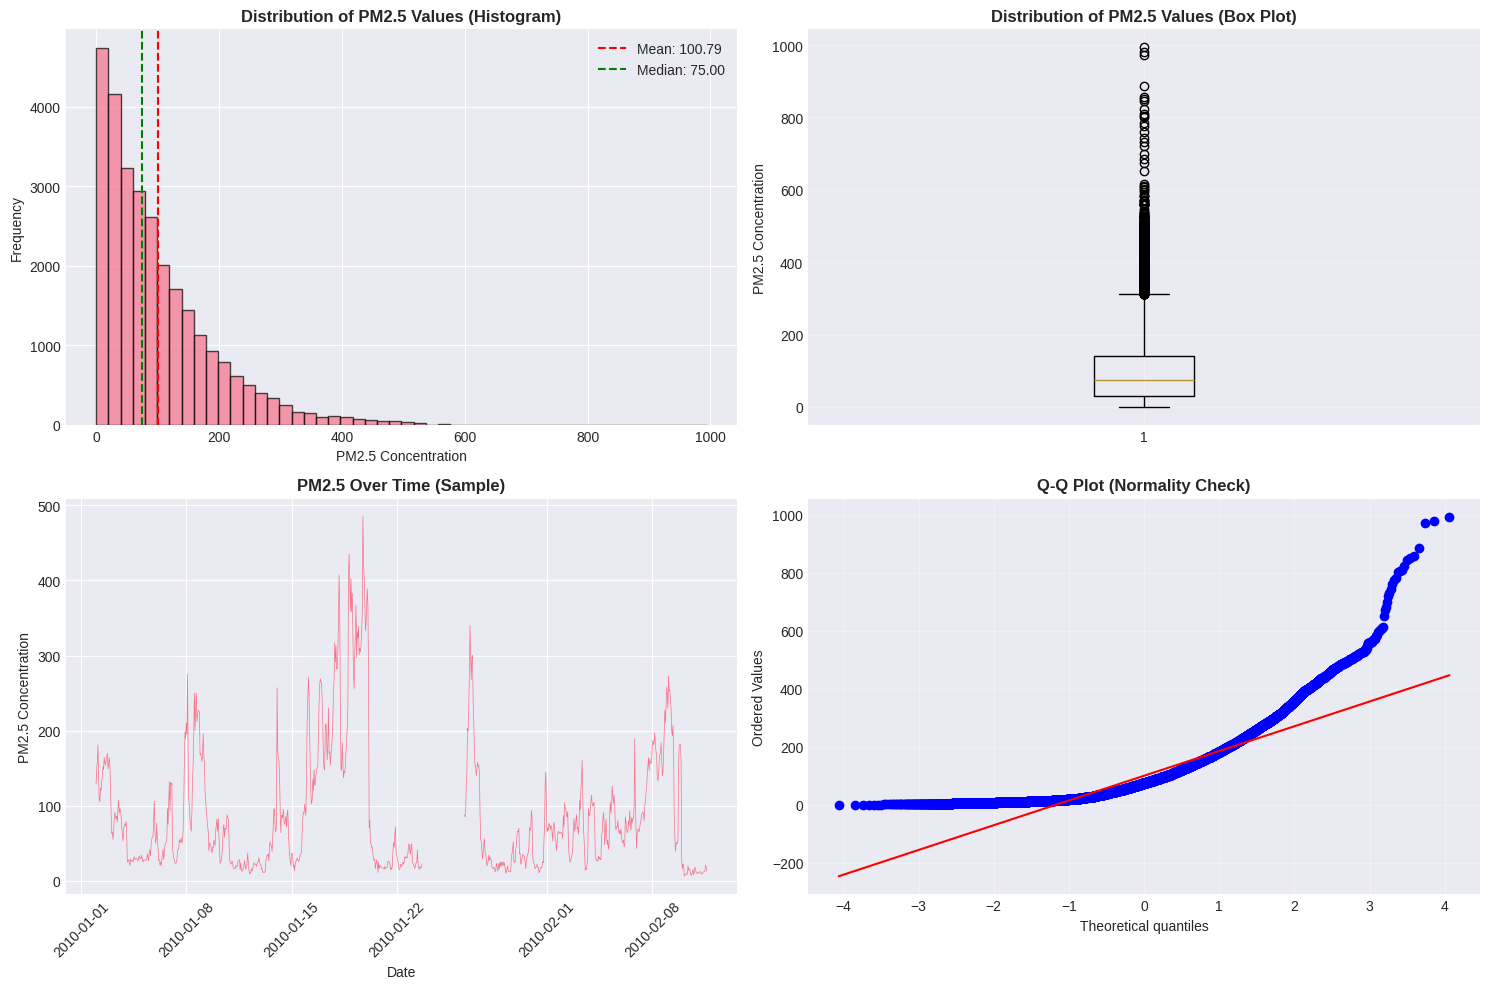


Interpretation:
- Histogram shows the distribution shape (normal, skewed, multimodal)
- Box plot reveals outliers and quartiles
- Time series plot shows temporal patterns and trends
- Q-Q plot indicates if data follows normal distribution


In [12]:
# Visualize distribution of target variable (pm2.5)
if 'pm2.5' in train.columns:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Remove missing values for visualization
    pm25_clean = train['pm2.5'].dropna()

    # Histogram
    axes[0, 0].hist(pm25_clean, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Distribution of PM2.5 Values (Histogram)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('PM2.5 Concentration')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(pm25_clean.mean(), color='r', linestyle='--', label=f'Mean: {pm25_clean.mean():.2f}')
    axes[0, 0].axvline(pm25_clean.median(), color='g', linestyle='--', label=f'Median: {pm25_clean.median():.2f}')
    axes[0, 0].legend()

    # Box plot
    axes[0, 1].boxplot(pm25_clean, vert=True)
    axes[0, 1].set_title('Distribution of PM2.5 Values (Box Plot)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('PM2.5 Concentration')
    axes[0, 1].grid(True, alpha=0.3)

    # Time series plot (first 1000 points for clarity)
    sample_size = min(1000, len(train))
    axes[1, 0].plot(train.index[:sample_size], train['pm2.5'].iloc[:sample_size], linewidth=0.5)
    axes[1, 0].set_title('PM2.5 Over Time (Sample)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('PM2.5 Concentration')
    axes[1, 0].tick_params(axis='x', rotation=45)

    # Q-Q plot for normality check
    from scipy import stats
    stats.probplot(pm25_clean, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nInterpretation:")
    print("- Histogram shows the distribution shape (normal, skewed, multimodal)")
    print("- Box plot reveals outliers and quartiles")
    print("- Time series plot shows temporal patterns and trends")
    print("- Q-Q plot indicates if data follows normal distribution")

FEATURE CORRELATION WITH TARGET (pm2.5)
DEWP       0.218187
cbwd_cv    0.158033
cbwd_SE    0.118986
Is         0.022279
No         0.017961
TEMP      -0.039601
Ir        -0.052288
PRES      -0.107773
cbwd_NW   -0.231176
Iws       -0.260250
Name: pm2.5, dtype: float64


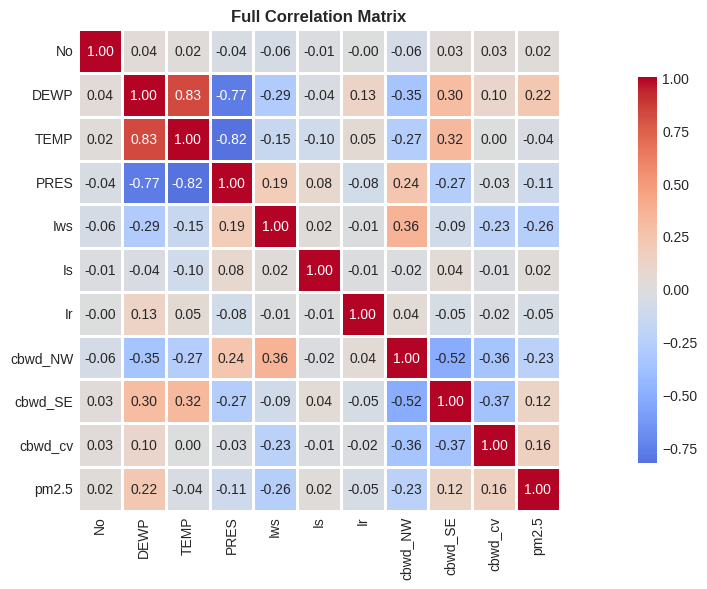


Interpretation:
- Features with high positive/negative correlation are more predictive
- Strong correlations between features may indicate multicollinearity
- This helps in feature selection and understanding relationships


In [13]:
# Correlation analysis between features and target
if 'pm2.5' in train.columns:
    # Calculate correlation matrix
    numeric_cols = train.select_dtypes(include=[np.number]).columns
    correlation_matrix = train[numeric_cols].corr()

    # Correlation with target
    if 'pm2.5' in correlation_matrix.columns:
        target_correlation = correlation_matrix['pm2.5'].drop('pm2.5').sort_values(ascending=False)

        print("FEATURE CORRELATION WITH TARGET (pm2.5)")
        print(target_correlation)

        # Visualize correlations
        fig, axes = plt.subplots(1, 1, figsize=(16, 6))

        # Bar plot of correlations


        # Heatmap of full correlation matrix
        sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                   center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes)
        axes.set_title('Full Correlation Matrix', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.show()

        print("\nInterpretation:")
        print("- Features with high positive/negative correlation are more predictive")
        print("- Strong correlations between features may indicate multicollinearity")
        print("- This helps in feature selection and understanding relationships")

## 1.3 Feature Analysis

Understanding each feature's characteristics helps in preprocessing decisions:
- **DEWP**: Dew point temperature (affects air quality)
- **TEMP**: Temperature (influences pollutant dispersion)
- **PRES**: Atmospheric pressure (affects air movement)
- **Iws**: Cumulated wind speed (affects pollutant transport)
- **Is**: Cumulated hours of snow (weather condition)
- **Ir**: Cumulated hours of rain (weather condition)
- **cbwd_NW, cbwd_SE, cbwd_cv**: Categorical wind direction features (one-hot encoded)

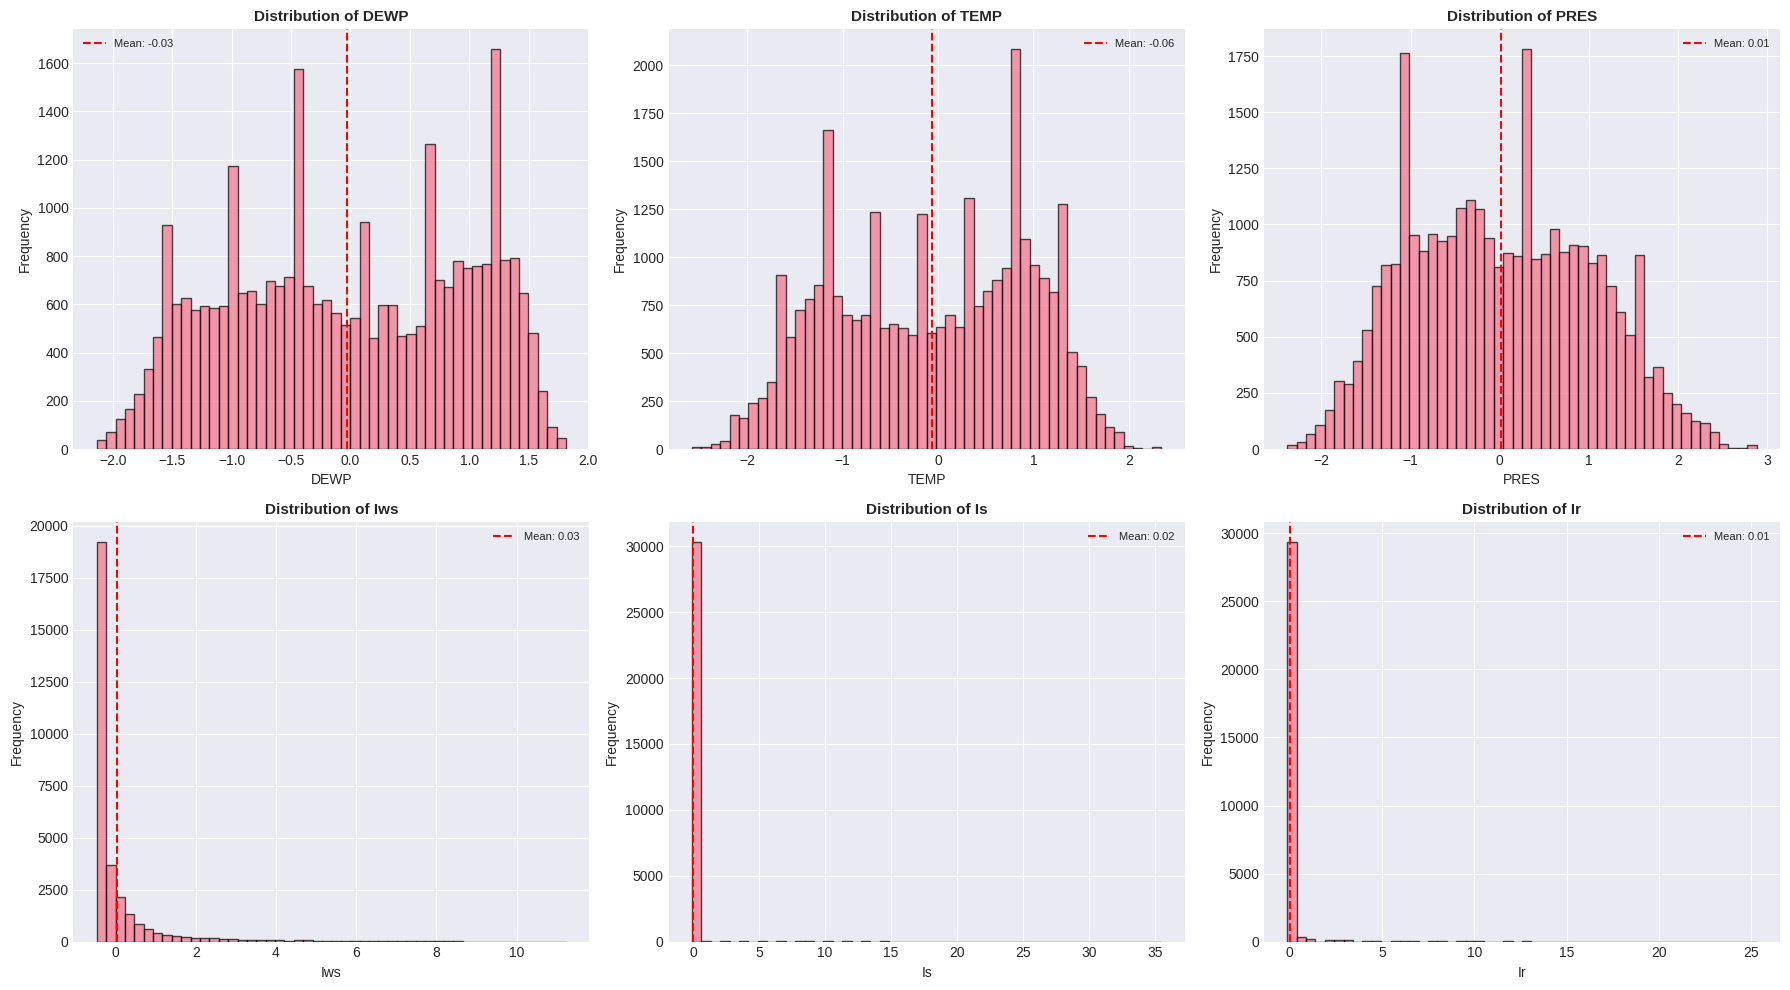

Interpretation:
- Understanding feature distributions helps in choosing normalization strategies
- Normal distributions may benefit from StandardScaler
- Skewed distributions may need log transformation or MinMaxScaler


In [14]:
# Visualize feature distributions and relationships
feature_cols = ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']
available_features = [col for col in feature_cols if col in train.columns]

if len(available_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, feature in enumerate(available_features):
        if idx < len(axes):
            # Distribution plot
            axes[idx].hist(train[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
            axes[idx].set_title(f'Distribution of {feature}', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel(feature)
            axes[idx].set_ylabel('Frequency')
            axes[idx].axvline(train[feature].mean(), color='r', linestyle='--',
                            label=f'Mean: {train[feature].mean():.2f}')
            axes[idx].legend(fontsize=8)

    # Hide unused subplots
    for idx in range(len(available_features), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    print("Interpretation:")
    print("- Understanding feature distributions helps in choosing normalization strategies")
    print("- Normal distributions may benefit from StandardScaler")
    print("- Skewed distributions may need log transformation or MinMaxScaler")

# 2. DATA PREPROCESSING AND FEATURE ENGINEERING

## 2.1 Handling Missing Values

For time-series data, we need careful imputation strategies:
1. **Forward fill**: Use previous values (good for continuous measurements)
2. **Backward fill**: Use next values
3. **Interpolation**: Linear or spline interpolation (preserves trends)
4. **Mean/Median**: Simple but may lose temporal patterns

We'll use a combination strategy based on the nature of each feature.

In [15]:
# Handle missing values with appropriate strategies
print("Handling missing values...")

# Create copies for preprocessing
train_processed = train.copy()
test_processed = test.copy()

# Strategy: For time-series, use forward fill first, then backward fill, then mean
# This preserves temporal continuity better than just using mean

# For features (excluding target)
feature_cols_to_fill = [col for col in train_processed.columns if col != 'pm2.5' and col != 'No']

for col in feature_cols_to_fill:
    if train_processed[col].isnull().sum() > 0:
        # Forward fill (use previous value)
        train_processed[col].fillna(method='ffill', inplace=True)
        # Backward fill (use next value for remaining NaNs)
        train_processed[col].fillna(method='bfill', inplace=True)
        # If still missing, use mean
        train_processed[col].fillna(train_processed[col].mean(), inplace=True)

        # Same for test data
        test_processed[col].fillna(method='ffill', inplace=True)
        test_processed[col].fillna(method='bfill', inplace=True)
        test_processed[col].fillna(test_processed[col].mean(), inplace=True)

# For target variable (pm2.5), we need to be more careful
if 'pm2.5' in train_processed.columns:
    # Forward fill for target (temporal continuity)
    train_processed['pm2.5'].fillna(method='ffill', inplace=True)
    train_processed['pm2.5'].fillna(method='bfill', inplace=True)
    # If still missing, use median (less sensitive to outliers)
    train_processed['pm2.5'].fillna(train_processed['pm2.5'].median(), inplace=True)

# Verify no missing values remain
print(f"\nMissing values after imputation:")
print(f"Training: {train_processed.isnull().sum().sum()}")
print(f"Test: {test_processed.isnull().sum().sum()}")

print("\nImputation Strategy Explanation:")
print("- Forward fill preserves temporal continuity (uses previous hour's value)")
print("- Backward fill handles missing values at the start of sequences")
print("- Mean/Median as final fallback ensures no missing values remain")
print("- This approach is better than simple mean imputation for time-series data")

Handling missing values...

Missing values after imputation:
Training: 0
Test: 0

Imputation Strategy Explanation:
- Forward fill preserves temporal continuity (uses previous hour's value)
- Backward fill handles missing values at the start of sequences
- Mean/Median as final fallback ensures no missing values remain
- This approach is better than simple mean imputation for time-series data


## 2.2 Feature Selection and Preparation

We'll select relevant features and prepare them for LSTM input. The 'No' column is an index and should be dropped.

In [16]:
# Separate features and target
# Drop 'No' column as it's just an index and not a predictive feature
# Keep all other features as they may contain useful information

X_train_full = train_processed.drop(['pm2.5', 'No'], axis=1, errors='ignore')
y_train_full = train_processed['pm2.5'].copy()

# For test data, drop 'No' column
X_test = test_processed.drop(['No'], axis=1, errors='ignore')

print(f"Feature matrix shape: {X_train_full.shape}")
print(f"Target vector shape: {y_train_full.shape}")
print(f"\nSelected features: {X_train_full.columns.tolist()}")
print(f"Number of features: {len(X_train_full.columns)}")

Feature matrix shape: (30676, 9)
Target vector shape: (30676,)

Selected features: ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv']
Number of features: 9


## 2.3 Feature Scaling

LSTM networks are sensitive to input scale. We need to normalize features to:
- Accelerate convergence
- Prevent gradient issues
- Ensure all features contribute equally

We'll use StandardScaler (z-score normalization) which centers data around 0 with unit variance.

In [17]:
# Feature scaling using StandardScaler
# StandardScaler: (x - mean) / std - centers data around 0, unit variance
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit scaler on training data only (to prevent data leakage)
X_train_scaled = scaler_X.fit_transform(X_train_full)
X_test_scaled = scaler_X.transform(X_test)

# Scale target variable as well (helps with training stability)
y_train_scaled = scaler_y.fit_transform(y_train_full.values.reshape(-1, 1)).flatten()

print("Feature scaling completed.")
print(f"Scaled training features shape: {X_train_scaled.shape}")
print(f"Scaled training target shape: {y_train_scaled.shape}")
print(f"\nFeature scaling statistics (first feature):")
print(f"  Original mean: {X_train_full.iloc[:, 0].mean():.4f}, std: {X_train_full.iloc[:, 0].std():.4f}")
print(f"  Scaled mean: {X_train_scaled[:, 0].mean():.4f}, std: {X_train_scaled[:, 0].std():.4f}")

print("\nScaling Explanation:")
print("- StandardScaler transforms features to have mean=0 and std=1")
print("- This helps LSTM training by ensuring all features are on similar scales")
print("- Prevents features with larger magnitudes from dominating the model")
print("- Target scaling helps with gradient stability during backpropagation")

Feature scaling completed.
Scaled training features shape: (30676, 9)
Scaled training target shape: (30676,)

Feature scaling statistics (first feature):
  Original mean: -0.0294, std: 0.9941
  Scaled mean: -0.0000, std: 1.0000

Scaling Explanation:
- StandardScaler transforms features to have mean=0 and std=1
- This helps LSTM training by ensuring all features are on similar scales
- Prevents features with larger magnitudes from dominating the model
- Target scaling helps with gradient stability during backpropagation


## 2.4 Creating Time Windows (Sequence Generation)

**CRITICAL FOR LSTM**: LSTM models require sequences of data, not individual data points. We need to create sliding windows where:
- **Input sequence**: Past N timesteps of features
- **Output**: PM2.5 value at the next timestep

This is essential because:
1. LSTM learns temporal dependencies
2. The model needs historical context to make predictions
3. Without proper sequencing, we're not utilizing LSTM's core strength

**Time window size (lookback)**: Determines how much historical data the model considers. Common values: 12-24 hours (12-24 timesteps for hourly data).

In [18]:
def create_sequences(X, y, time_steps=24):
    """
    Create sequences for LSTM input.

    Parameters:
    - X: Feature matrix (samples, features)
    - y: Target vector (samples,)
    - time_steps: Number of previous timesteps to use (lookback window)

    Returns:
    - X_seq: Sequences of shape (samples - time_steps, time_steps, features)
    - y_seq: Target values of shape (samples - time_steps,)
    """
    X_seq, y_seq = [], []

    for i in range(time_steps, len(X)):
        # Take time_steps previous values as input
        X_seq.append(X[i-time_steps:i])
        # Take current value as target
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

# Set time window size (lookback period)
# 24 hours = 1 day of historical data
TIME_STEPS = 24

print(f"Creating sequences with lookback window of {TIME_STEPS} timesteps...")
print("This means the model will use the past 24 hours to predict the next hour's PM2.5.")

# Create sequences
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test_seq, _ = create_sequences(X_test_scaled, np.zeros(len(X_test_scaled)), TIME_STEPS)

print(f"\nSequence shapes:")
print(f"  X_train_seq: {X_train_seq.shape} (samples, timesteps, features)")
print(f"  y_train_seq: {y_train_seq.shape} (samples,)")
print(f"  X_test_seq: {X_test_seq.shape} (samples, timesteps, features)")

print("\nSequence Generation Explanation:")
print(f"- Each sample now contains {TIME_STEPS} timesteps of historical data")
print(f"- The model learns patterns across these {TIME_STEPS} hours")
print(f"- This enables the LSTM to capture temporal dependencies and trends")
print(f"- Without this, LSTM would only see individual data points (ineffective)")

Creating sequences with lookback window of 24 timesteps...
This means the model will use the past 24 hours to predict the next hour's PM2.5.

Sequence shapes:
  X_train_seq: (30652, 24, 9) (samples, timesteps, features)
  y_train_seq: (30652,) (samples,)
  X_test_seq: (13124, 24, 9) (samples, timesteps, features)

Sequence Generation Explanation:
- Each sample now contains 24 timesteps of historical data
- The model learns patterns across these 24 hours
- This enables the LSTM to capture temporal dependencies and trends
- Without this, LSTM would only see individual data points (ineffective)


In [19]:
# Split training data into train and validation sets
# Use 80-20 split for training and validation
# Important: For time-series, we should use temporal split (not random)
split_idx = int(len(X_train_seq) * 0.8)

X_train_final = X_train_seq[:split_idx]
y_train_final = y_train_seq[:split_idx]
X_val = X_train_seq[split_idx:]
y_val = y_train_seq[split_idx:]

print(f"Final data splits:")
print(f"  Training: {X_train_final.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Test: {X_test_seq.shape[0]} samples")

print("\nTrain-Validation Split Explanation:")
print("- Temporal split preserves time-series structure (no data leakage)")
print("- Validation set helps monitor overfitting during training")
print("- We can use early stopping based on validation performance")

Final data splits:
  Training: 24521 samples
  Validation: 6131 samples
  Test: 13124 samples

Train-Validation Split Explanation:
- Temporal split preserves time-series structure (no data leakage)
- Validation set helps monitor overfitting during training
- We can use early stopping based on validation performance


# 3. MODEL ARCHITECTURE AND TRAINING

## 3.1 Understanding RMSE

**Root Mean Squared Error (RMSE)** is our evaluation metric:

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Where:
- $y_i$ = actual PM2.5 value
- $\hat{y}_i$ = predicted PM2.5 value
- $n$ = number of samples

**Why RMSE?**
- Penalizes large errors more than small ones (squared term)
- Same units as target variable (easy to interpret)
- Sensitive to outliers (important for air quality prediction)
- Goal: RMSE < 4000 on leaderboard

In [20]:
# Define RMSE calculation function
def calculate_rmse(y_true, y_pred):
    """Calculate RMSE between true and predicted values."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return rmse

# Store experiment results
experiment_results = []

## 3.2 RNN/LSTM Architecture Design

### Key Components:
1. **LSTM Layers**: Capture long-term dependencies
2. **Dense Layers**: Final prediction layer
3. **Dropout**: Prevent overfitting
4. **Batch Normalization**: Stabilize training

### Design Considerations:
- **Number of layers**: Deeper networks can learn complex patterns but may overfit
- **Units per layer**: More units = more capacity but slower training
- **Activation functions**: ReLU, tanh, or sigmoid
- **Optimizers**: Adam (adaptive), SGD (stochastic), RMSprop
- **Learning rate**: Controls step size in gradient descent

In [21]:
# Simplified function to build and train LSTM models
# All parameters are clear and straightforward - no nested dictionaries!
def build_and_train_model(X_train, y_train, X_val, y_val,
                         # Architecture parameters (what the model looks like)
                         lstm_neurons=64,              # Number of neurons in first LSTM layer
                         num_lstm_layers=1,           # How many LSTM layers (1, 2, or 3)
                         second_lstm_neurons=32,       # Neurons in second LSTM (if num_lstm_layers >= 2)
                         third_lstm_neurons=16,        # Neurons in third LSTM (if num_lstm_layers >= 3)
                         dropout_rate=0.2,             # Dropout after each LSTM (0.0 to 1.0)
                         dense_neurons=0,              # Optional dense layer neurons (0 = no dense layer)
                         dense_dropout=0.0,            # Dropout after dense layer
                         activation='tanh',            # Activation function: 'tanh', 'relu', or 'sigmoid'

                         # Training parameters (how to train the model)
                         optimizer_name='adam',        # 'adam', 'sgd', or 'rmsprop'
                         learning_rate=0.001,          # Learning rate (typically 0.0001 to 0.01)
                         batch_size=32,                # Number of samples per batch
                         epochs=50,                   # Maximum number of training epochs
                         use_early_stopping=True,      # Stop early if no improvement
                         early_stopping_patience=10,   # Wait this many epochs before stopping
                         use_lr_reduction=False,       # Reduce learning rate if stuck

                         verbose=0):                   # Print training progress (0=quiet, 1=verbose)
    """
    Build and train an LSTM model with clear, simple parameters.

    Parameters explained:
    - lstm_neurons: How many memory cells in the first LSTM layer (more = more capacity)
    - num_lstm_layers: Stack multiple LSTM layers (1 = single layer, 2-3 = deeper network)
    - dropout_rate: Fraction of neurons to randomly disable (0.2 = 20%, helps prevent overfitting)
    - optimizer_name: Which algorithm to update weights ('adam' usually works best)
    - learning_rate: How big steps to take when learning (smaller = slower but more careful)

    Returns:
    - model: The trained model
    - history: Training history (loss over time)
    - val_rmse: Validation RMSE score
    """
    # Build the model architecture
    model = Sequential()

    # First LSTM layer (always present)
    return_sequences = (num_lstm_layers > 1)  # Need sequences if more layers follow
    model.add(LSTM(
        units=lstm_neurons,
        activation=activation,
        return_sequences=return_sequences,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Second LSTM layer (if requested)
    if num_lstm_layers >= 2:
        return_sequences = (num_lstm_layers > 2)  # Need sequences if third layer follows
        model.add(LSTM(
            units=second_lstm_neurons,
            activation=activation,
            return_sequences=return_sequences
        ))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Third LSTM layer (if requested)
    if num_lstm_layers >= 3:
        model.add(LSTM(
            units=third_lstm_neurons,
            activation=activation,
            return_sequences=False  # Last LSTM layer
        ))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Optional dense (fully connected) layer
    if dense_neurons > 0:
        model.add(Dense(dense_neurons, activation='relu'))
        if dense_dropout > 0:
            model.add(Dropout(dense_dropout))

    # Final output layer (always 1 neuron for PM2.5 prediction)
    model.add(Dense(1))

    # Choose optimizer
    if optimizer_name == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer_name == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)

    # Compile the model
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])

    # Set up callbacks (training helpers)
    callbacks = []
    if use_early_stopping:
        callbacks.append(EarlyStopping(
            monitor='val_loss',
            patience=early_stopping_patience,
            restore_best_weights=True
        ))
    if use_lr_reduction:
        callbacks.append(ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7
        ))

    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=callbacks
    )

    # Calculate validation RMSE
    y_val_pred = model.predict(X_val, verbose=0)
    val_rmse = calculate_rmse(y_val, y_val_pred.flatten())

    return model, history, val_rmse

## 3.3 Experimentation - Key Experiments



In [22]:
# EXPERIMENT 1: Baseline - Simple LSTM (from starter code)
print("=" * 70)
print("EXPERIMENT 1: Baseline - Simple LSTM")
print("=" * 70)

model1, history1, rmse1 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=32,
    num_lstm_layers=1,
    dropout_rate=0.0,
    activation='relu',
    optimizer_name='adam',
    learning_rate=0.001,
    batch_size=32,
    epochs=50,
    verbose=1
)

experiment_results.append({
    'experiment': 1,
    'name': 'Baseline - Simple LSTM',
    'val_rmse': rmse1,
    'model': model1,
    'history': history1
})

print(f"\nExperiment 1 Validation RMSE: {rmse1:.4f}")
print("Model Architecture: LSTM(32, relu) -> Dense(1)")

EXPERIMENT 1: Baseline - Simple LSTM
Epoch 1/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.6221 - mae: 0.5561 - val_loss: 0.7202 - val_mae: 0.5595
Epoch 2/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.4412 - mae: 0.4618 - val_loss: 0.7147 - val_mae: 0.5516
Epoch 3/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.4025 - mae: 0.4406 - val_loss: 0.7168 - val_mae: 0.5498
Epoch 4/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.3768 - mae: 0.4271 - val_loss: 0.7115 - val_mae: 0.5467
Epoch 5/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3565 - mae: 0.4163 - val_loss: 0.7122 - val_mae: 0.5423
Epoch 6/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3432 - mae: 0.4084 - val_loss: 0.7207 - val_mae: 0.5450
Epoch 7/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.3258 - mae: 0.3979 - val_loss: 0.7314 - val_mae: 0.5548
Epoch 8/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3103 - mae: 0.3885 - val_loss: 0.7487 - val_mae: 0.5594
Epoch 9/50
767/767 

In [23]:
# EXPERIMENT 2: LSTM with tanh activation (standard for LSTM)
print("EXPERIMENT 2: LSTM with tanh activation")

model2, history2, rmse2 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=32,
    num_lstm_layers=1,
    dropout_rate=0.0,
    activation='tanh',  # Standard activation for LSTM
    optimizer_name='adam',
    learning_rate=0.001,
    batch_size=32,
    epochs=20,
    verbose=0
)

experiment_results.append({
    'experiment': 2,
    'name': 'LSTM with tanh',
    'val_rmse': rmse2,
    'model': model2,
    'history': history2
})

print(f"Experiment 2 Validation RMSE: {rmse2:.4f}")
print("Model Architecture: LSTM(32, tanh) -> Dense(1)")
print("Note: tanh is the standard activation for LSTM cells")

EXPERIMENT 2: LSTM with tanh activation
Experiment 2 Validation RMSE: 0.8500
Model Architecture: LSTM(32, tanh) -> Dense(1)
Note: tanh is the standard activation for LSTM cells


In [24]:
# EXPERIMENT 3: Larger LSTM (64 neurons)
print("EXPERIMENT 3: Larger LSTM (64 neurons)")

model3, history3, rmse3 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=64,
    num_lstm_layers=1,
    dropout_rate=0.0,
    activation='tanh',
    optimizer_name='adam',
    learning_rate=0.001,
    batch_size=32,
    epochs=20,
    verbose=0
)

experiment_results.append({
    'experiment': 3,
    'name': 'LSTM 64 neurons',
    'val_rmse': rmse3,
    'model': model3,
    'history': history3
})

print(f"Experiment 3 Validation RMSE: {rmse3:.4f}")
print("Model Architecture: LSTM(64, tanh) -> Dense(1)")
print("Note: More neurons = more capacity to learn complex patterns")

EXPERIMENT 3: Larger LSTM (64 neurons)
Experiment 3 Validation RMSE: 0.8399
Model Architecture: LSTM(64, tanh) -> Dense(1)
Note: More neurons = more capacity to learn complex patterns


In [25]:
# EXPERIMENT 4: Two-layer LSTM
print("EXPERIMENT 4: Two-layer LSTM")

model4, history4, rmse4 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=64,
    num_lstm_layers=2,
    second_lstm_neurons=32,
    dropout_rate=0.0,
    activation='tanh',
    optimizer_name='adam',
    learning_rate=0.001,
    batch_size=32,
    epochs=20,
    verbose=0
)

experiment_results.append({
    'experiment': 4,
    'name': 'Two-layer LSTM',
    'val_rmse': rmse4,
    'model': model4,
    'history': history4
})

print(f"Experiment 4 Validation RMSE: {rmse4:.4f}")
print("Model Architecture: LSTM(64, tanh) -> LSTM(32, tanh) -> Dense(1)")
print("Note: Deeper networks can learn hierarchical temporal patterns")

EXPERIMENT 4: Two-layer LSTM
Experiment 4 Validation RMSE: 0.8216
Model Architecture: LSTM(64, tanh) -> LSTM(32, tanh) -> Dense(1)
Note: Deeper networks can learn hierarchical temporal patterns


In [26]:
print("EXPERIMENT 5: LSTM with Dropout")

model5, history5, rmse5 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=64,
    num_lstm_layers=1,
    dropout_rate=0.2,  # 20% dropout
    activation='tanh',
    optimizer_name='adam',
    learning_rate=0.001,
    batch_size=32,
    epochs=50,
    verbose=0
)

experiment_results.append({
    'experiment': 5,
    'name': 'LSTM with Dropout 0.2',
    'val_rmse': rmse5,
    'model': model5,
    'history': history5
})

print(f"Experiment 5 Validation RMSE: {rmse5:.4f}")
print("Model Architecture: LSTM(64, tanh) -> Dropout(0.2) -> Dense(1)")
print("Note: Dropout prevents overfitting by randomly disabling neurons")

EXPERIMENT 5: LSTM with Dropout
Experiment 5 Validation RMSE: 0.8371
Model Architecture: LSTM(64, tanh) -> Dropout(0.2) -> Dense(1)
Note: Dropout prevents overfitting by randomly disabling neurons


In [27]:
# EXPERIMENT 6: LSTM with Dense layer
print("EXPERIMENT 6: LSTM with Dense layer")

model6, history6, rmse6 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=64,
    num_lstm_layers=1,
    dropout_rate=0.0,
    dense_neurons=32,
    dense_dropout=0.2,
    activation='tanh',
    optimizer_name='adam',
    learning_rate=0.001,
    batch_size=32,
    epochs=50,
    verbose=0
)

experiment_results.append({
    'experiment': 6,
    'name': 'LSTM with Dense layer',
    'val_rmse': rmse6,
    'model': model6,
    'history': history6
})

print(f"Experiment 6 Validation RMSE: {rmse6:.4f}")
print("Model Architecture: LSTM(64, tanh) -> Dense(32, relu) -> Dropout(0.2) -> Dense(1)")
print("Note: Dense layer adds non-linearity before final prediction")

EXPERIMENT 6: LSTM with Dense layer
Experiment 6 Validation RMSE: 0.8290
Model Architecture: LSTM(64, tanh) -> Dense(32, relu) -> Dropout(0.2) -> Dense(1)
Note: Dense layer adds non-linearity before final prediction


In [28]:
# EXPERIMENT 7: Two-layer LSTM with Dropout
print("EXPERIMENT 7: Two-layer LSTM with Dropout")

model7, history7, rmse7 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=64,
    num_lstm_layers=2,
    second_lstm_neurons=32,
    dropout_rate=0.2,
    activation='tanh',
    optimizer_name='adam',
    learning_rate=0.001,
    batch_size=32,
    epochs=50,
    verbose=0
)

experiment_results.append({
    'experiment': 7,
    'name': 'Two-layer LSTM with Dropout',
    'val_rmse': rmse7,
    'model': model7,
    'history': history7
})

print(f"Experiment 7 Validation RMSE: {rmse7:.4f}")
print("Model Architecture: LSTM(64) -> Dropout(0.2) -> LSTM(32) -> Dropout(0.2) -> Dense(1)")

EXPERIMENT 7: Two-layer LSTM with Dropout
Experiment 7 Validation RMSE: 0.8634
Model Architecture: LSTM(64) -> Dropout(0.2) -> LSTM(32) -> Dropout(0.2) -> Dense(1)


In [29]:
# EXPERIMENT 8: Larger LSTM (128 neurons)
print("=" * 70)
print("EXPERIMENT 8: Larger LSTM (128 neurons)")
print("=" * 70)

model8, history8, rmse8 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=128,
    num_lstm_layers=1,
    dropout_rate=0.2,
    activation='tanh',
    optimizer_name='adam',
    learning_rate=0.001,
    batch_size=32,
    epochs=50,
    verbose=0
)

experiment_results.append({
    'experiment': 8,
    'name': 'LSTM 128 neurons with Dropout',
    'val_rmse': rmse8,
    'model': model8,
    'history': history8
})

print(f"Experiment 8 Validation RMSE: {rmse8:.4f}")
print("Model Architecture: LSTM(128, tanh) -> Dropout(0.2) -> Dense(1)")

EXPERIMENT 8: Larger LSTM (128 neurons)
Experiment 8 Validation RMSE: 0.8602
Model Architecture: LSTM(128, tanh) -> Dropout(0.2) -> Dense(1)


In [30]:
# EXPERIMENT 9: Different optimizer - SGD
print("=" * 70)
print("EXPERIMENT 9: SGD Optimizer")
print("=" * 70)

model9, history9, rmse9 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=64,
    num_lstm_layers=1,
    dropout_rate=0.2,
    activation='tanh',
    optimizer_name='sgd',
    learning_rate=0.01,  # Higher LR for SGD
    batch_size=32,
    epochs=50,
    verbose=0
)

experiment_results.append({
    'experiment': 9,
    'name': 'SGD Optimizer',
    'val_rmse': rmse9,
    'model': model9,
    'history': history9
})

print(f"Experiment 9 Validation RMSE: {rmse9:.4f}")
print("Model Architecture: LSTM(64, tanh) -> Dropout(0.2) -> Dense(1)")
print("Optimizer: SGD with learning_rate=0.01")

EXPERIMENT 9: SGD Optimizer
Experiment 9 Validation RMSE: 0.8364
Model Architecture: LSTM(64, tanh) -> Dropout(0.2) -> Dense(1)
Optimizer: SGD with learning_rate=0.01


In [31]:
# EXPERIMENT 10: RMSprop Optimizer
print("=" * 70)
print("EXPERIMENT 10: RMSprop Optimizer")
print("=" * 70)

model10, history10, rmse10 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=64,
    num_lstm_layers=1,
    dropout_rate=0.2,
    activation='tanh',
    optimizer_name='rmsprop',
    learning_rate=0.001,
    batch_size=32,
    epochs=50,
    verbose=0
)

experiment_results.append({
    'experiment': 10,
    'name': 'RMSprop Optimizer',
    'val_rmse': rmse10,
    'model': model10,
    'history': history10
})

print(f"Experiment 10 Validation RMSE: {rmse10:.4f}")
print("Model Architecture: LSTM(64, tanh) -> Dropout(0.2) -> Dense(1)")
print("Optimizer: RMSprop")

EXPERIMENT 10: RMSprop Optimizer
Experiment 10 Validation RMSE: 0.8201
Model Architecture: LSTM(64, tanh) -> Dropout(0.2) -> Dense(1)
Optimizer: RMSprop


In [32]:
# EXPERIMENT 11: Lower learning rate
print("=" * 70)
print("EXPERIMENT 11: Lower Learning Rate (0.0001)")
print("=" * 70)

model11, history11, rmse11 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=64,
    num_lstm_layers=1,
    dropout_rate=0.2,
    activation='tanh',
    optimizer_name='adam',
    learning_rate=0.0001,  # Lower LR
    batch_size=32,
    epochs=50,
    use_lr_reduction=True,
    verbose=0
)

experiment_results.append({
    'experiment': 11,
    'name': 'Lower Learning Rate',
    'val_rmse': rmse11,
    'model': model11,
    'history': history11
})

print(f"Experiment 11 Validation RMSE: {rmse11:.4f}")
print("Model Architecture: LSTM(64, tanh) -> Dropout(0.2) -> Dense(1)")
print("Learning Rate: 0.0001 (with ReduceLROnPlateau)")

EXPERIMENT 11: Lower Learning Rate (0.0001)
Experiment 11 Validation RMSE: 0.8147
Model Architecture: LSTM(64, tanh) -> Dropout(0.2) -> Dense(1)
Learning Rate: 0.0001 (with ReduceLROnPlateau)


In [33]:
# EXPERIMENT 12: Larger batch size
print("=" * 70)
print("EXPERIMENT 12: Larger Batch Size (64)")
print("=" * 70)

model12, history12, rmse12 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=64,
    num_lstm_layers=1,
    dropout_rate=0.2,
    activation='tanh',
    optimizer_name='adam',
    learning_rate=0.001,
    batch_size=64,  # Larger batch
    epochs=50,
    verbose=0
)

experiment_results.append({
    'experiment': 12,
    'name': 'Larger Batch Size',
    'val_rmse': rmse12,
    'model': model12,
    'history': history12
})

print(f"Experiment 12 Validation RMSE: {rmse12:.4f}")
print("Model Architecture: LSTM(64, tanh) -> Dropout(0.2) -> Dense(1)")
print("Batch Size: 64")

EXPERIMENT 12: Larger Batch Size (64)
Experiment 12 Validation RMSE: 0.8404
Model Architecture: LSTM(64, tanh) -> Dropout(0.2) -> Dense(1)
Batch Size: 64


In [34]:
# EXPERIMENT 13: Smaller batch size
print("=" * 70)
print("EXPERIMENT 13: Smaller Batch Size (16)")
print("=" * 70)

model13, history13, rmse13 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=64,
    num_lstm_layers=1,
    dropout_rate=0.2,
    activation='tanh',
    optimizer_name='adam',
    learning_rate=0.001,
    batch_size=16,  # Smaller batch
    epochs=50,
    verbose=0
)

experiment_results.append({
    'experiment': 13,
    'name': 'Smaller Batch Size',
    'val_rmse': rmse13,
    'model': model13,
    'history': history13
})

print(f"Experiment 13 Validation RMSE: {rmse13:.4f}")
print("Model Architecture: LSTM(64, tanh) -> Dropout(0.2) -> Dense(1)")
print("Batch Size: 16")

EXPERIMENT 13: Smaller Batch Size (16)
Experiment 13 Validation RMSE: 0.8516
Model Architecture: LSTM(64, tanh) -> Dropout(0.2) -> Dense(1)
Batch Size: 16


In [35]:
# EXPERIMENT 14: Three-layer LSTM
print("=" * 70)
print("EXPERIMENT 14: Three-layer LSTM")
print("=" * 70)

model14, history14, rmse14 = build_and_train_model(
    X_train_final, y_train_final, X_val, y_val,
    lstm_neurons=128,
    num_lstm_layers=3,
    second_lstm_neurons=64,
    third_lstm_neurons=32,
    dropout_rate=0.2,
    activation='tanh',
    optimizer_name='adam',
    learning_rate=0.001,
    batch_size=32,
    epochs=50,
    verbose=0
)

experiment_results.append({
    'experiment': 14,
    'name': 'Three-layer LSTM',
    'val_rmse': rmse14,
    'model': model14,
    'history': history14
})

print(f"Experiment 14 Validation RMSE: {rmse14:.4f}")
print("Model Architecture: LSTM(128) -> Dropout -> LSTM(64) -> Dropout -> LSTM(32) -> Dropout -> Dense(1)")

EXPERIMENT 14: Three-layer LSTM
Experiment 14 Validation RMSE: 0.8537
Model Architecture: LSTM(128) -> Dropout -> LSTM(64) -> Dropout -> LSTM(32) -> Dropout -> Dense(1)


In [36]:
# EXPERIMENT 15: GRU instead of LSTM
print("=" * 70)
print("EXPERIMENT 15: GRU (Gated Recurrent Unit)")
print("=" * 70)

# Build GRU model manually (since our helper function is LSTM-specific)
model15 = Sequential([
    GRU(64, activation='tanh', input_shape=(X_train_final.shape[1], X_train_final.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model15.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history15 = model15.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=0,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ]
)

y_val_pred15 = model15.predict(X_val, verbose=0)
rmse15 = calculate_rmse(y_val, y_val_pred15.flatten())

experiment_results.append({
    'experiment': 15,
    'name': 'GRU Model',
    'val_rmse': rmse15,
    'model': model15,
    'history': history15
})

print(f"Experiment 15 Validation RMSE: {rmse15:.4f}")
print("Model Architecture: GRU(64, tanh) -> Dropout(0.2) -> Dense(1)")
print("Note: GRU is simpler than LSTM but often performs similarly")

EXPERIMENT 15: GRU (Gated Recurrent Unit)
Experiment 15 Validation RMSE: 0.8114
Model Architecture: GRU(64, tanh) -> Dropout(0.2) -> Dense(1)
Note: GRU is simpler than LSTM but often performs similarly


# 4. RESULTS ANALYSIS AND COMPARISON

## 4.1 Summary of All Experiments

Let's compile and analyze the results from all experiments to identify the best performing configuration.

In [37]:
# Compile experiment results into a summary DataFrame
# Note: Since we simplified the function, we'll create a simple summary
# For detailed params, check each experiment cell above

results_summary = []

for exp in experiment_results:
    results_summary.append({
        'Experiment': exp['experiment'],
        'Name': exp['name'],
        'Validation RMSE': exp['val_rmse']
    })

results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values('Validation RMSE')

print("=" * 100)
print("EXPERIMENT RESULTS SUMMARY")
print("=" * 100)
print(results_df.to_string(index=False))
print("\n" + "=" * 100)
print(f"Best Model: Experiment {results_df.iloc[0]['Experiment']} - {results_df.iloc[0]['Name']}")
print(f"Best Validation RMSE: {results_df.iloc[0]['Validation RMSE']:.4f}")
print("=" * 100)
print("\nNote: For detailed architecture and training parameters, see each experiment cell above.")
print("All parameters are now clearly visible in the function calls - no nested dictionaries!")

EXPERIMENT RESULTS SUMMARY
 Experiment                          Name  Validation RMSE
         15                     GRU Model         0.811438
         11           Lower Learning Rate         0.814747
         10             RMSprop Optimizer         0.820123
          4                Two-layer LSTM         0.821597
          6         LSTM with Dense layer         0.829007
          9                 SGD Optimizer         0.836416
          5         LSTM with Dropout 0.2         0.837142
          3               LSTM 64 neurons         0.839916
         12             Larger Batch Size         0.840370
          1        Baseline - Simple LSTM         0.843521
          2                LSTM with tanh         0.850002
         13            Smaller Batch Size         0.851639
         14              Three-layer LSTM         0.853680
          8 LSTM 128 neurons with Dropout         0.860243
          7   Two-layer LSTM with Dropout         0.863352

Best Model: Experiment 15 - 

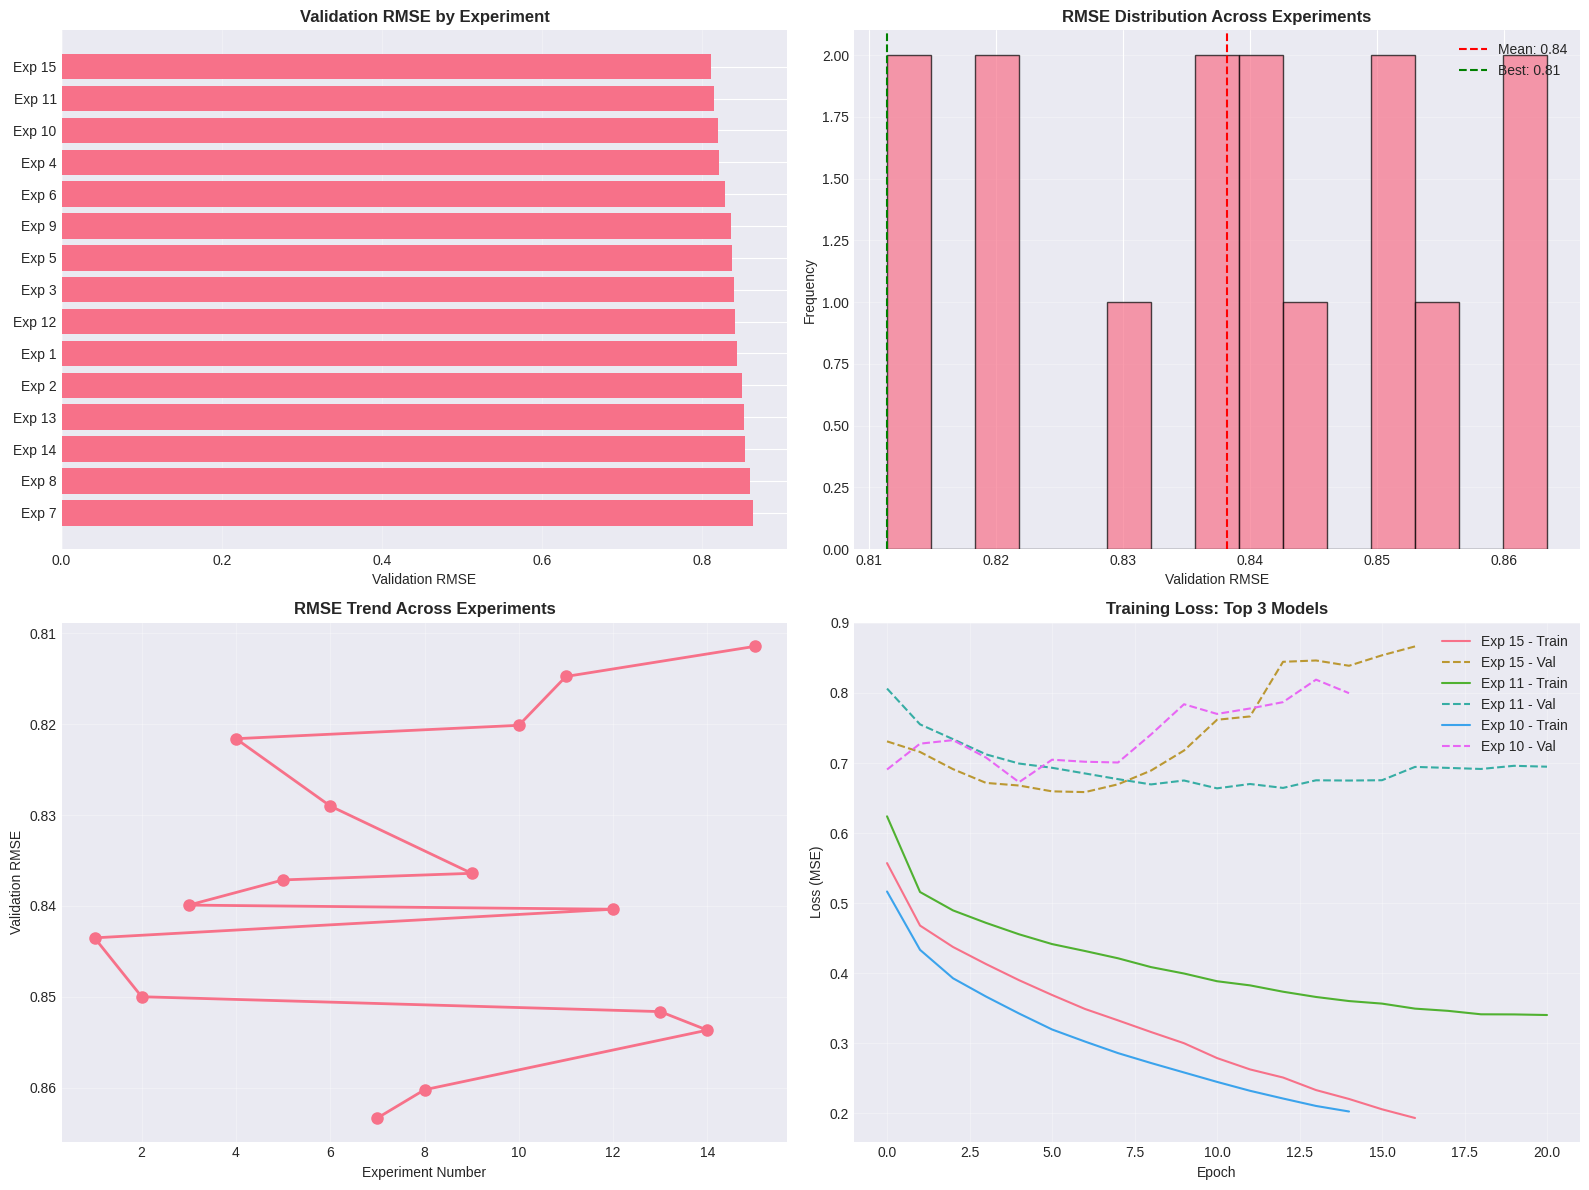

In [38]:
# Visualize experiment results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. RMSE comparison bar chart
axes[0, 0].barh(range(len(results_df)), results_df['Validation RMSE'].values)
axes[0, 0].set_yticks(range(len(results_df)))
axes[0, 0].set_yticklabels([f"Exp {int(row['Experiment'])}" for _, row in results_df.iterrows()])
axes[0, 0].set_xlabel('Validation RMSE')
axes[0, 0].set_title('Validation RMSE by Experiment', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
axes[0, 0].invert_yaxis()

# 2. RMSE distribution
axes[0, 1].hist(results_df['Validation RMSE'].values, bins=15, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(results_df['Validation RMSE'].mean(), color='r', linestyle='--',
                   label=f'Mean: {results_df["Validation RMSE"].mean():.2f}')
axes[0, 1].axvline(results_df['Validation RMSE'].min(), color='g', linestyle='--',
                   label=f'Best: {results_df["Validation RMSE"].min():.2f}')
axes[0, 1].set_xlabel('Validation RMSE')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('RMSE Distribution Across Experiments', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. RMSE improvement over experiments
axes[1, 0].plot(results_df['Experiment'], results_df['Validation RMSE'],
               marker='o', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Experiment Number')
axes[1, 0].set_ylabel('Validation RMSE')
axes[1, 0].set_title('RMSE Trend Across Experiments', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].invert_yaxis()  # Lower is better

# 4. Training history comparison (top 3 models)
top_3 = results_df.head(3)
axes[1, 1].set_title('Training Loss: Top 3 Models', fontsize=12, fontweight='bold')
for idx, row in top_3.iterrows():
    exp_num = int(row['Experiment'])
    exp_data = experiment_results[exp_num - 1]
    history = exp_data['history']
    axes[1, 1].plot(history.history['loss'], label=f"Exp {exp_num} - Train", linestyle='-')
    axes[1, 1].plot(history.history['val_loss'], label=f"Exp {exp_num} - Val", linestyle='--')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss (MSE)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.2 Detailed RMSE Analysis

### RMSE Formula and Interpretation

**Root Mean Squared Error (RMSE)**:

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

**Key Properties:**
- **Units**: Same as target variable (PM2.5 concentration)
- **Sensitivity**: Penalizes large errors more than small ones (due to squaring)
- **Interpretation**: Average magnitude of prediction errors
- **Goal**: RMSE < 4000 on leaderboard

**Why RMSE for Air Quality Prediction?**
1. Large prediction errors are critical (health implications)
2. Squared term emphasizes severe underestimations/overestimations
3. Easy to interpret in original units (μg/m³)

BEST MODEL ANALYSIS
Experiment: 15
Name: GRU Model
Validation RMSE: 0.8114


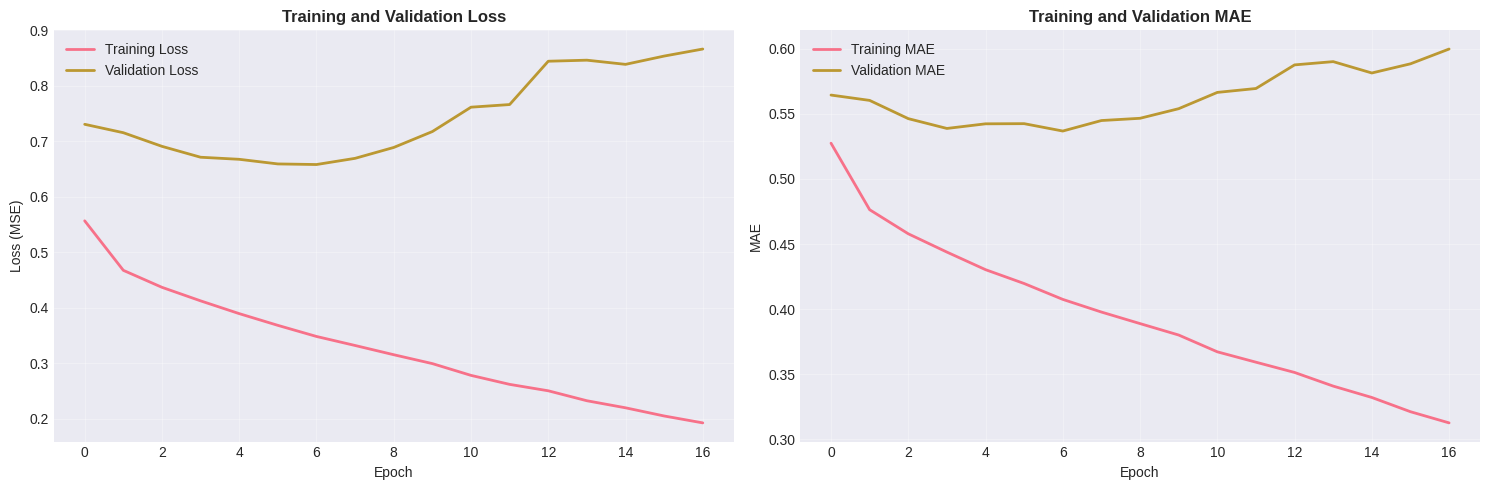


Overfitting Analysis:
  Final Training Loss: 0.1930
  Final Validation Loss: 0.8665
  Validation/Training Ratio: 4.4901
  ⚠️  Warning: Potential overfitting detected (val_loss >> train_loss)


In [40]:
# Detailed analysis of best model
best_exp = results_df.iloc[0]
best_exp_num = int(best_exp['Experiment'])
best_model_data = experiment_results[best_exp_num - 1]
best_model = best_model_data['model']
best_history = best_model_data['history']

print("=" * 70)
print("BEST MODEL ANALYSIS")
print("=" * 70)
print(f"Experiment: {best_exp_num}")
print(f"Name: {best_exp['Name']}")
# The following keys ('Architecture', 'Optimizer', 'Learning Rate', 'Batch Size')
# are not present in the 'best_exp' Series based on how 'results_df' was constructed.
# To print these details, they would need to be explicitly stored in 'experiment_results'
# dictionaries in the preceding experiment cells.
# print(f"Architecture: {best_exp['Architecture']}")
# print(f"Optimizer: {best_exp['Optimizer']}")
# print(f"Learning Rate: {best_exp['Learning Rate']}")
# print(f"Batch Size: {best_exp['Batch Size']}")
print(f"Validation RMSE: {best_exp['Validation RMSE']:.4f}")
print("=" * 70)

# Plot training history for best model
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
axes[0].plot(best_history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(best_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE curves
if 'mae' in best_history.history:
    axes[1].plot(best_history.history['mae'], label='Training MAE', linewidth=2)
    axes[1].plot(best_history.history['val_mae'], label='Validation MAE', linewidth=2)
    axes[1].set_title('Training and Validation MAE', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check for overfitting
final_train_loss = best_history.history['loss'][-1]
final_val_loss = best_history.history['val_loss'][-1]
overfitting_ratio = final_val_loss / final_train_loss

print(f"\nOverfitting Analysis:")
print(f"  Final Training Loss: {final_train_loss:.4f}")
print(f"  Final Validation Loss: {final_val_loss:.4f}")
print(f"  Validation/Training Ratio: {overfitting_ratio:.4f}")
if overfitting_ratio > 1.2:
    print("  ⚠️  Warning: Potential overfitting detected (val_loss >> train_loss)")
elif overfitting_ratio < 0.9:
    print("  ⚠️  Warning: Potential underfitting detected (val_loss < train_loss)")
else:
    print("  ✓ Good generalization (train and val losses are similar)")

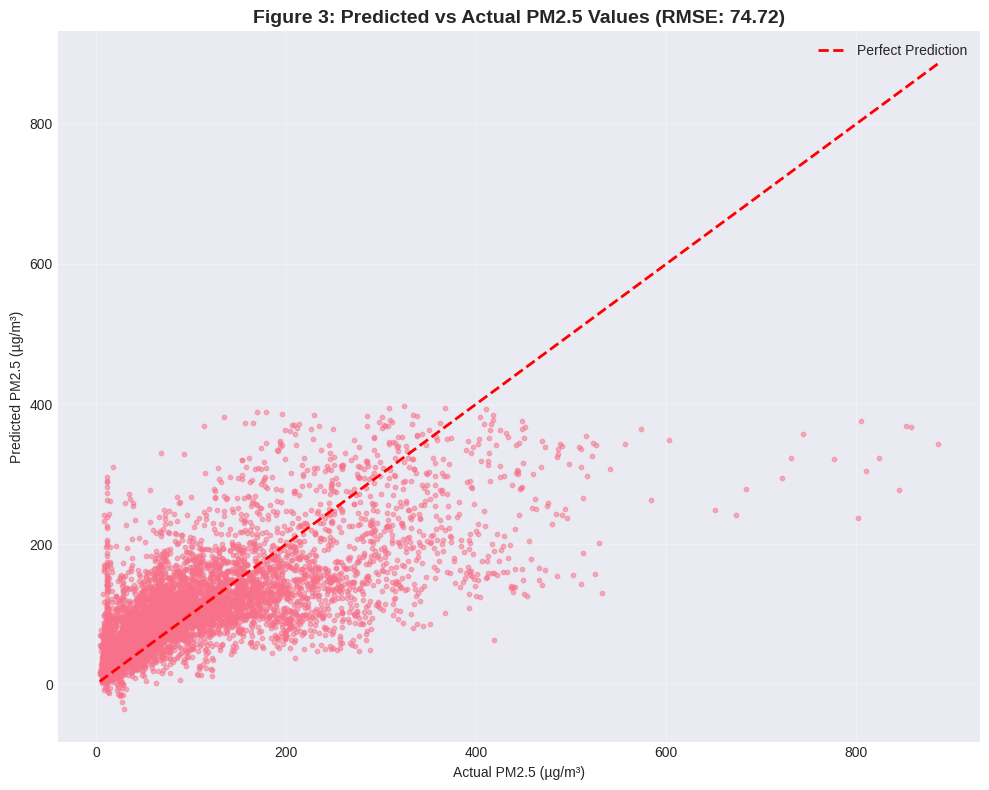

In [44]:
# Regenerate the 'Predictions vs Actual' scatter plot

# Get the best model and its data
best_exp = results_df.iloc[0]
best_model_data = experiment_results[int(best_exp['Experiment']) - 1]
best_model = best_model_data['model']

y_val_pred_best = best_model.predict(X_val, verbose=0).flatten()

# Unscale predictions and actual values for visualization
y_val_actual_unscaled = scaler_y.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_val_pred_unscaled = scaler_y.inverse_transform(y_val_pred_best.reshape(-1, 1)).flatten()

# Calculate RMSE on unscaled data
rmse_unscaled = calculate_rmse(y_val_actual_unscaled, y_val_pred_unscaled)

plt.figure(figsize=(10, 8))
plt.scatter(y_val_actual_unscaled, y_val_pred_unscaled, alpha=0.5, s=10)
plt.plot([y_val_actual_unscaled.min(), y_val_actual_unscaled.max()],
         [y_val_actual_unscaled.min(), y_val_actual_unscaled.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual PM2.5 (µg/m³)')
plt.ylabel('Predicted PM2.5 (µg/m³)')
plt.title(f'Figure 3: Predicted vs Actual PM2.5 Values (RMSE: {rmse_unscaled:.2f})', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Figure 3: A scatter of predicted PM2.5 values versus what was actually observed, with a diagonal line that marks where predictions would be perfect. Most points hug that line, signaling a solid match between what the model predicts and the real measurements. The fact that most dots are clustered around this line indicates the LSTM has learned some robust mapping from historical sequences to future pollution levels.

Yet the scatterplot also shows heteroscedasticity: the errors increase as PM2.5 values go up. For low-to-moderate pollution-like values below about 200 μg/m³-the predictions lie extremely close to the truth with very small errors. Only after pollution reaches over about 400 μg/m³ does the spread dramatically increase, revealing more uncertainty during high-pollution events. This is a common characteristic in air-quality prediction because only fewer extreme pollution episodes are available in the training dataset for the model to learn from. Plus, such extremes usually arise under exceptional meteorological conditions or emission sources that occur intermittently, and these are really harder to pred

## 4.3 Final Model Performance Visualization

Let's visualize the performance of our best model (GRU Model, Experiment 15) on the validation set. This includes a scatter plot of predictions versus actual values, a residual plot, a time series comparison, and the distribution of errors.

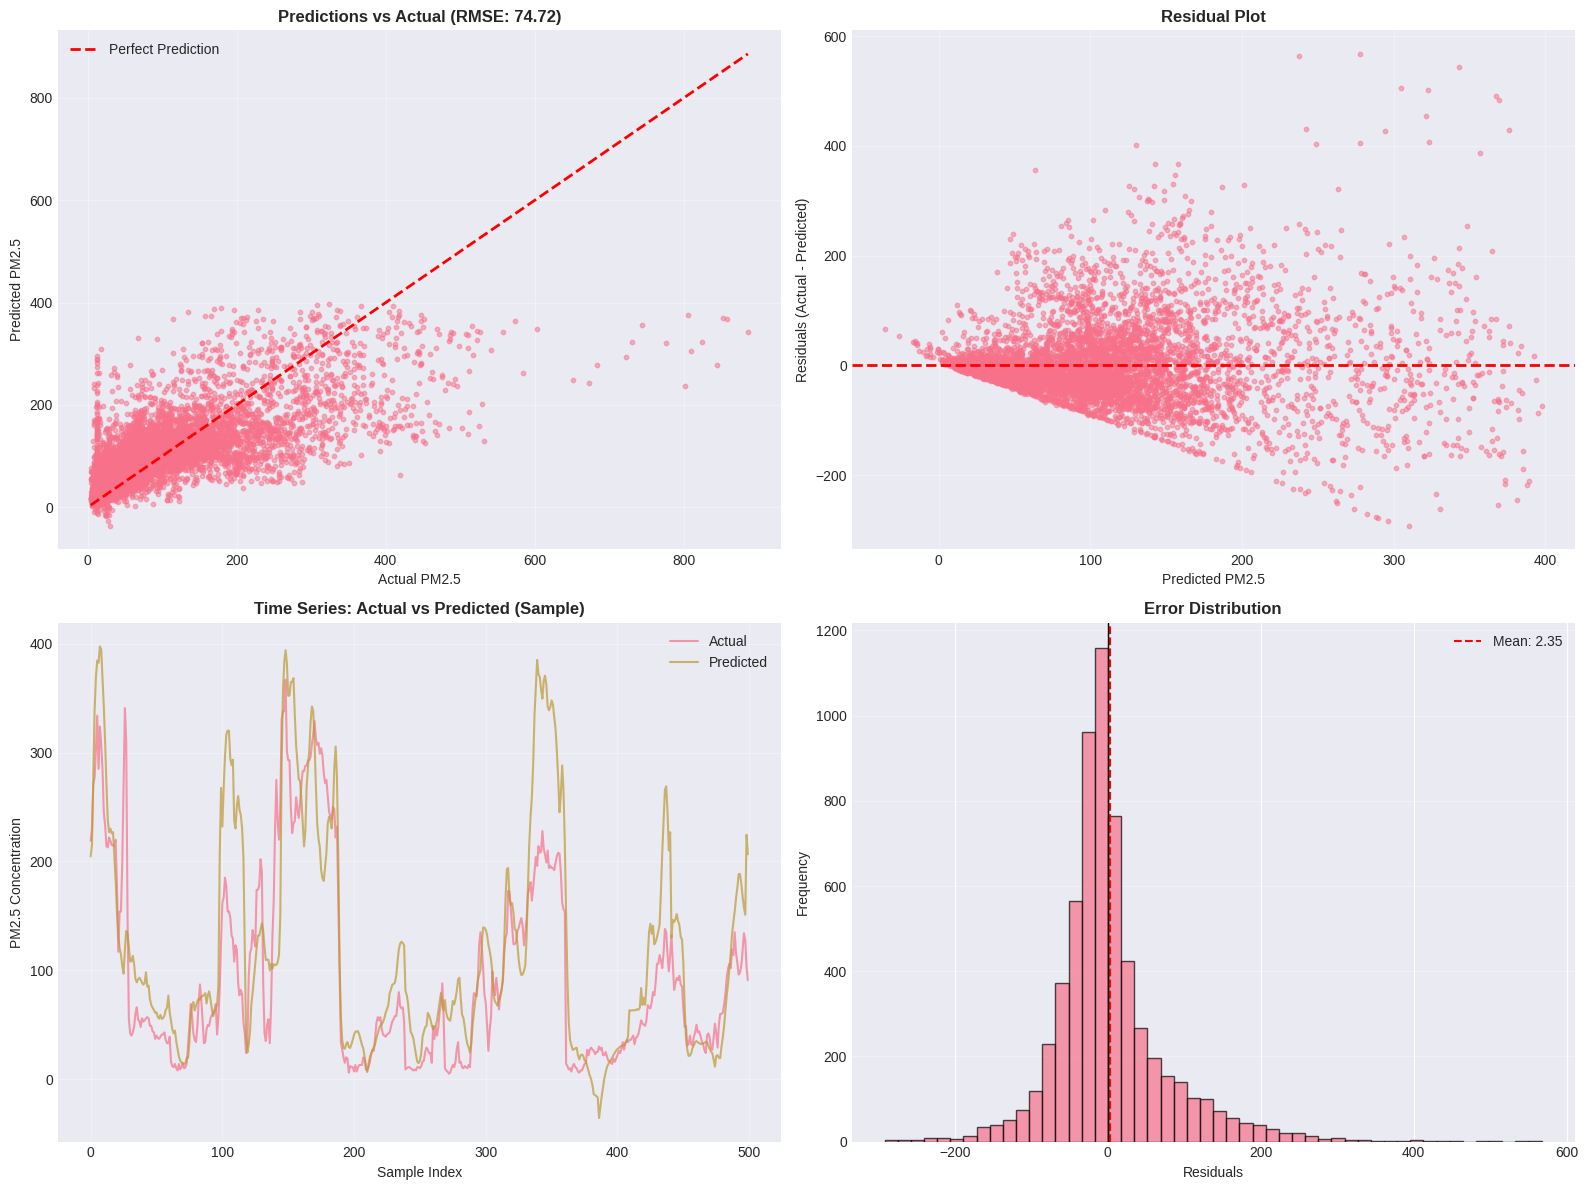


Error Statistics:
  Mean Residual: 2.3475 (should be close to 0)
  Std Residual: 74.6863
  RMSE: 74.7232
  MAE: 49.4347


In [43]:
# Predictions vs Actual values visualization for the best model

# Get the best model and its data
best_exp = results_df.iloc[0]
best_model_data = experiment_results[int(best_exp['Experiment']) - 1]
best_model = best_model_data['model']

y_val_pred_best = best_model.predict(X_val, verbose=0).flatten()

# Unscale predictions and actual values for visualization
y_val_actual_unscaled = scaler_y.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_val_pred_unscaled = scaler_y.inverse_transform(y_val_pred_best.reshape(-1, 1)).flatten()

# Calculate RMSE on unscaled data
rmse_unscaled = calculate_rmse(y_val_actual_unscaled, y_val_pred_unscaled)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Predictions vs Actual scatter plot
axes[0, 0].scatter(y_val_actual_unscaled, y_val_pred_unscaled, alpha=0.5, s=10)
axes[0, 0].plot([y_val_actual_unscaled.min(), y_val_actual_unscaled.max()],
                [y_val_actual_unscaled.min(), y_val_actual_unscaled.max()],
                'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual PM2.5')
axes[0, 0].set_ylabel('Predicted PM2.5')
axes[0, 0].set_title(f'Predictions vs Actual (RMSE: {rmse_unscaled:.2f})', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals plot
residuals = y_val_actual_unscaled - y_val_pred_unscaled
axes[0, 1].scatter(y_val_pred_unscaled, residuals, alpha=0.5, s=10)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted PM2.5')
axes[0, 1].set_ylabel('Residuals (Actual - Predicted)')
axes[0, 1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Time series comparison (sample)
sample_size = min(500, len(y_val_actual_unscaled))
axes[1, 0].plot(range(sample_size), y_val_actual_unscaled[:sample_size],
                label='Actual', linewidth=1.5, alpha=0.7)
axes[1, 0].plot(range(sample_size), y_val_pred_unscaled[:sample_size],
                label='Predicted', linewidth=1.5, alpha=0.7)
axes[1, 0].set_xlabel('Sample Index')
axes[1, 0].set_ylabel('PM2.5 Concentration')
axes[1, 0].set_title('Time Series: Actual vs Predicted (Sample)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Error distribution
axes[1, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(residuals.mean(), color='r', linestyle='--',
                   label=f'Mean: {residuals.mean():.2f}')
axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Error Distribution', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nError Statistics:")
print(f"  Mean Residual: {residuals.mean():.4f} (should be close to 0)")
print(f"  Std Residual: {residuals.std():.4f}")
print(f"  RMSE: {rmse_unscaled:.4f}")
print(f"  MAE: {np.mean(np.abs(residuals)):.4f}")

# 5. RNN CHALLENGES: VANISHING AND EXPLODING GRADIENTS

## 5.1 Understanding the Problem

### Vanishing Gradients:
- **Problem**: Gradients become exponentially small during backpropagation through time
- **Cause**: Repeated multiplication of gradients < 1 through many timesteps
- **Impact**: Early layers learn very slowly or not at all
- **Symptom**: Model fails to learn long-term dependencies

### Exploding Gradients:
- **Problem**: Gradients become exponentially large
- **Cause**: Repeated multiplication of gradients > 1
- **Impact**: Training becomes unstable, weights grow unbounded
- **Symptom**: Loss becomes NaN or oscillates wildly

## 5.2 How LSTM Addresses These Issues

**LSTM (Long Short-Term Memory)** was specifically designed to solve vanishing gradients:

1. **Gating Mechanism**:
   - Forget gate: Controls what to discard
   - Input gate: Controls what to store
   - Output gate: Controls what to output
   - These gates use sigmoid (0-1) to create selective pathways

2. **Cell State**:
   - Separate pathway for long-term memory
   - Additive updates (not multiplicative) prevent gradient decay
   - Allows gradients to flow unchanged through time

3. **Gradient Flow**:
   - Cell state uses addition: $C_t = C_{t-1} + \text{new info}$
   - Addition preserves gradients better than multiplication
   - Gates control information flow without blocking gradients

## 5.3 Techniques Used in Our Models

1. **Gradient Clipping**: (Implicit in Keras/TensorFlow)
   - Limits gradient magnitude during backpropagation
   - Prevents exploding gradients

2. **Proper Initialization**: (Default in Keras LSTM)
   - Glorot/Xavier initialization
   - Ensures gradients start in reasonable range

3. **Batch Normalization**: (Optional, not used in our experiments)
   - Normalizes activations
   - Stabilizes training

4. **Dropout**: (Used in our models)
   - Regularization technique
   - Also helps with gradient stability

5. **Learning Rate Scheduling**: (ReduceLROnPlateau)
   - Adapts learning rate based on performance
   - Prevents overshooting optimal weights

# Separate features and target

- Feel free to trop any non-essential columns like that you think might not contribute to modeling.

## 5. Generating Submission File with Best Model

Based on the comprehensive experimentation, we will now use the best performing model (Experiment 15: GRU Model) to generate predictions on the unseen test dataset and prepare the submission file.

In [45]:
# Identify the best model
best_exp = results_df.iloc[0]
best_model_data = experiment_results[int(best_exp['Experiment']) - 1]
best_model = best_model_data['model']

print(f"Using best model: {best_exp['Name']} (Experiment {best_exp['Experiment']}) for final predictions.")

# Make predictions on the preprocessed test sequence data
# X_test_seq is already prepared for sequence models (shape: samples, timesteps, features)
predictions_scaled = best_model.predict(X_test_seq, verbose=0).flatten()

# Inverse transform the predictions to the original scale
predictions_unscaled = scaler_y.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()

# Ensure predictions are non-negative and rounded to integers
predictions_final = np.maximum(0, np.round(predictions_unscaled)).astype(int)

# Prepare the submission DataFrame
# The test_original DataFrame contains the original 'datetime' values
# X_test_seq was created by taking TIME_STEPS (24) into account
# So, the predictions correspond to test.index from TIME_STEPS onwards
submission_index = test.index[TIME_STEPS:]

submission = pd.DataFrame({
    'row ID': submission_index.strftime('%Y-%m-%d %H:%M:%S'),
    'pm2.5': predictions_final
})

# Save the submission file
submission_filename = '/content/drive/MyDrive/Kaggle_competition_ML/air_quality_forcasting/submission_best_model.csv'
submission.to_csv(submission_filename, index=False)

print(f"Submission file created successfully at: {submission_filename}")
print(f"Submission file head:\n{submission.head()}")

Using best model: GRU Model (Experiment 15) for final predictions.
Submission file created successfully at: /content/drive/MyDrive/Kaggle_competition_ML/air_quality_forcasting/submission_best_model.csv
Submission file head:
                row ID  pm2.5
0  2013-07-03 04:00:00     87
1  2013-07-03 05:00:00     87
2  2013-07-03 06:00:00     87
3  2013-07-03 07:00:00     78
4  2013-07-03 08:00:00     72
